In [1]:
import pickle as pkl
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt 
import seaborn as sns

from tqdm import tqdm
from pathlib import Path 

In [2]:
rank_path = Path("/home/wuhlmann/BA/data/processed_data/SA/ranks")
nse_path = Path("/home/wuhlmann/BA/data/processed_data/SA/raw_NSE")

rank_file_list = list(rank_path.glob("*.p"))
nse_file_list = list(nse_path.glob("*.p"))

rank_dict = {}
nse_dict = {} 


In [3]:
for rank_path in rank_file_list: 
    
	with open(rank_path, "rb") as f: 
		rank_dict.update(pkl.load(f))
	
rank_dict = dict(sorted(rank_dict.items(), key=lambda item: int(item[0])))

for nse_path in nse_file_list: 
    
	with open(nse_path, "rb") as f: 
		nse_dict.update(pkl.load(f))
	
nse_dict = dict(sorted(nse_dict.items(), key=lambda item: int(item[0])))

In [4]:
nse_dict["116"]

,-1.00,-0.75,-0.50,-0.25,-0.10,0.10,0.25,0.50,0.75,1.00
area_calc,0.101144,0.071191,0.043853,0.019775,0.007360,0.006534,0.014707,0.024171,0.028939,0.029202
elev_mean,0.887177,0.098700,0.005217,0.014550,0.008501,0.012418,0.038167,0.091346,0.124980,0.133192
elev_ran,0.023380,0.020881,0.016438,0.009623,0.004224,0.004715,0.012481,0.026947,0.043544,0.061202
slope_mean,0.018495,0.019957,0.017472,0.011010,0.005021,0.005970,0.017001,0.042556,0.078508,0.120622
p_mean,0.018851,0.011291,0.005604,0.000840,0.000363,0.001734,0.007201,0.025686,0.044208,0.059366
et0_mean,0.000182,0.004271,0.005459,0.003522,0.001499,0.001537,0.003807,0.007662,0.013457,0.026203
arid_1,0.206782,0.135217,0.076269,0.031035,0.010565,0.007943,0.015036,0.016373,0.005276,0.037567
p_season,0.063980,0.036131,0.020509,0.011420,0.004897,0.004960,0.011711,0.018232,0.016299,0.004640
hi_prec_fr,0.000847,0.007583,0.014819,0.015959,0.008656,0.011143,0.030168,0.054380,0.058842,0.055539
hi_prec_du,0.016651,0.005240,0.001076,0.002756,0.001589,0.002295,0.007073,0.018522,0.034262,0.053768


In [21]:
strata_ids = pd.read_table("/home/wuhlmann/BA/data/processed_data/test_splits/strata_ids_incl_651.txt", header=0, sep=",")
strata_ids.set_index("ID", inplace=True)

lamah_gdf = gpd.read_file("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
lamah_gdf.set_index("ID", inplace=True)
lamah_gdf["strata"] = strata_ids["0"]
lamah_gdf.sort_index(ascending=True, inplace=True)

strata_labels = {
	"alpine":0,
	"plateau": 1,
	"transition": 2
}

In [22]:
# Calculate the attribute sensitivity ranking per basin. 
for id in tqdm(list(nse_dict.keys())):

	# Get df.
	basin_df = nse_dict[id]

	stds = basin_df.var(axis=1)

	stds = (stds - stds.mean()) / stds.std()
	
	lamah_gdf.loc[int(id), "top"] = stds.sort_values().index[-1]
	lamah_gdf.loc[int(id), "2nd"] = stds.sort_values().index[-2]
	lamah_gdf.loc[int(id), "3rd"] = stds.sort_values().index[-3]

	for attr in	stds.index: 
		
		lamah_gdf.loc[int(id), f"{attr}_nse_var"] = stds.loc[attr]

100%|██████████| 859/859 [00:05<00:00, 169.95it/s]


Display all attributes ranks over the domain.

In [ ]:
plt.rcParams['figure.dpi'] = 300

29it [00:19,  1.46it/s]


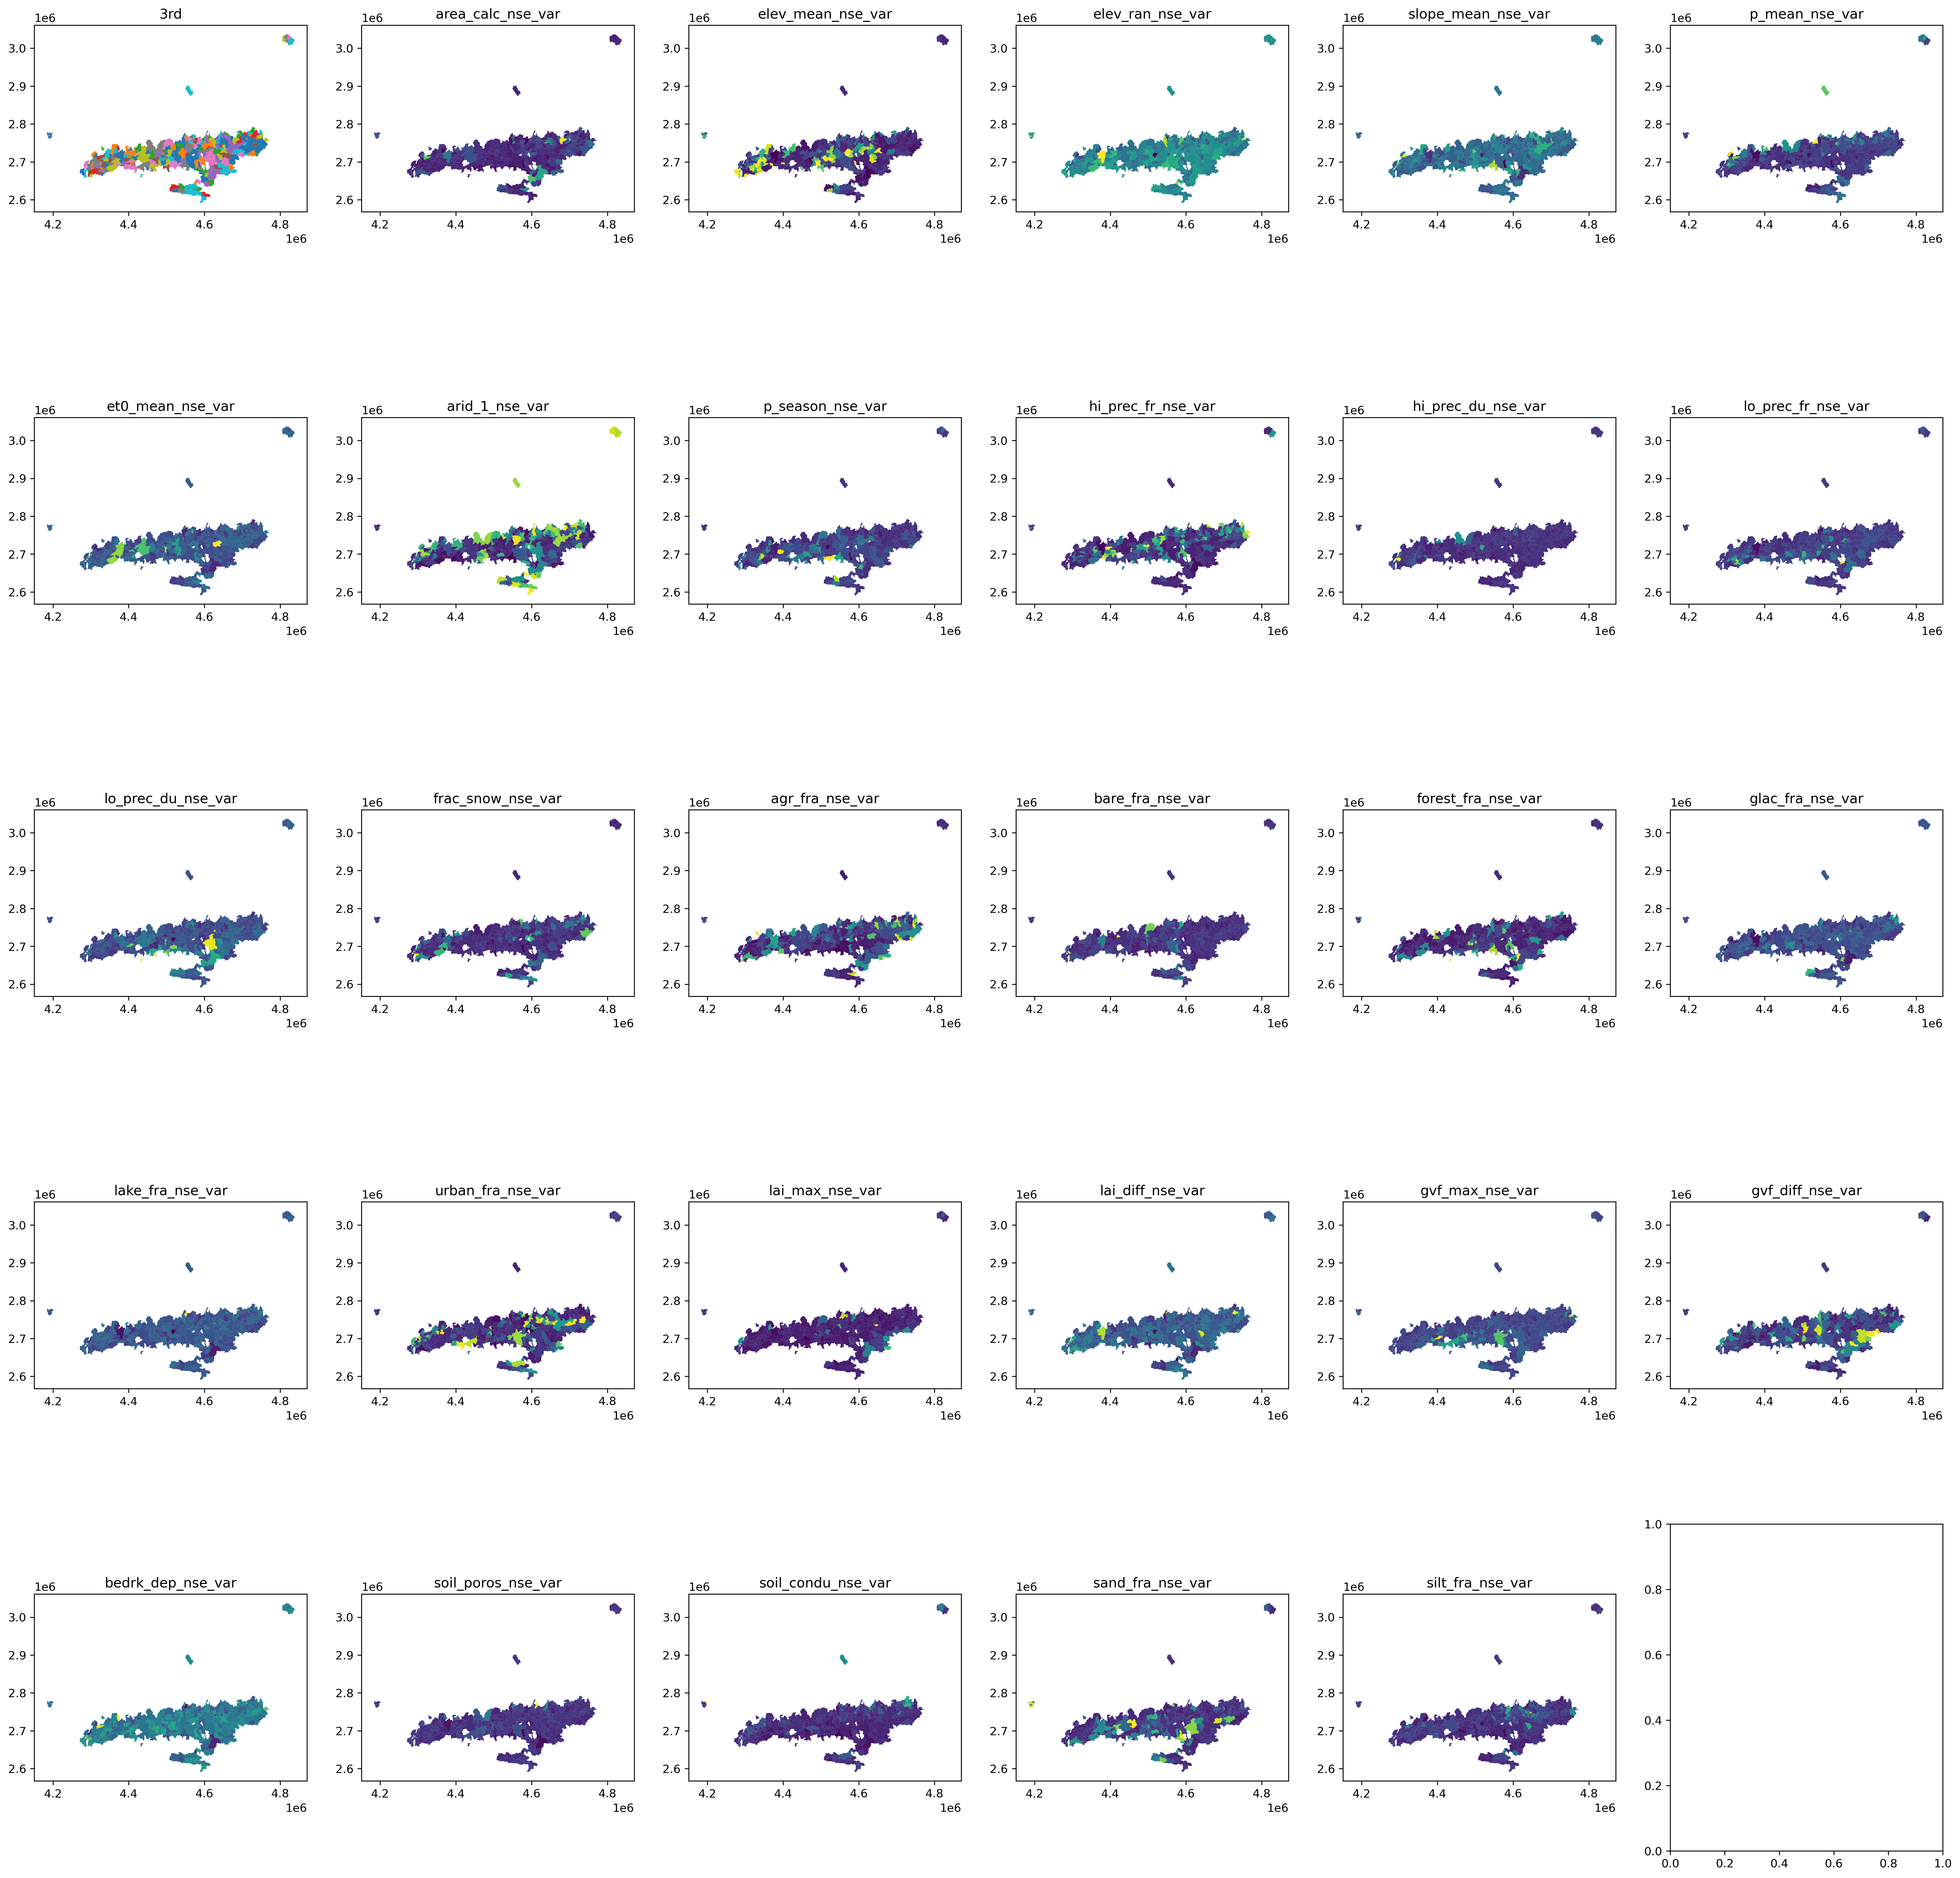

In [25]:
fig, axs = plt.subplots(5,6, figsize=(30,30))

for ax, attr in tqdm(zip(axs.ravel(), list(lamah_gdf.columns[-30:-1]))):
	
	lamah_gdf[lamah_gdf.strata == strata_labels["transition"]].plot(column=attr, ax=ax)
	ax.set_title(attr)


<Axes: >

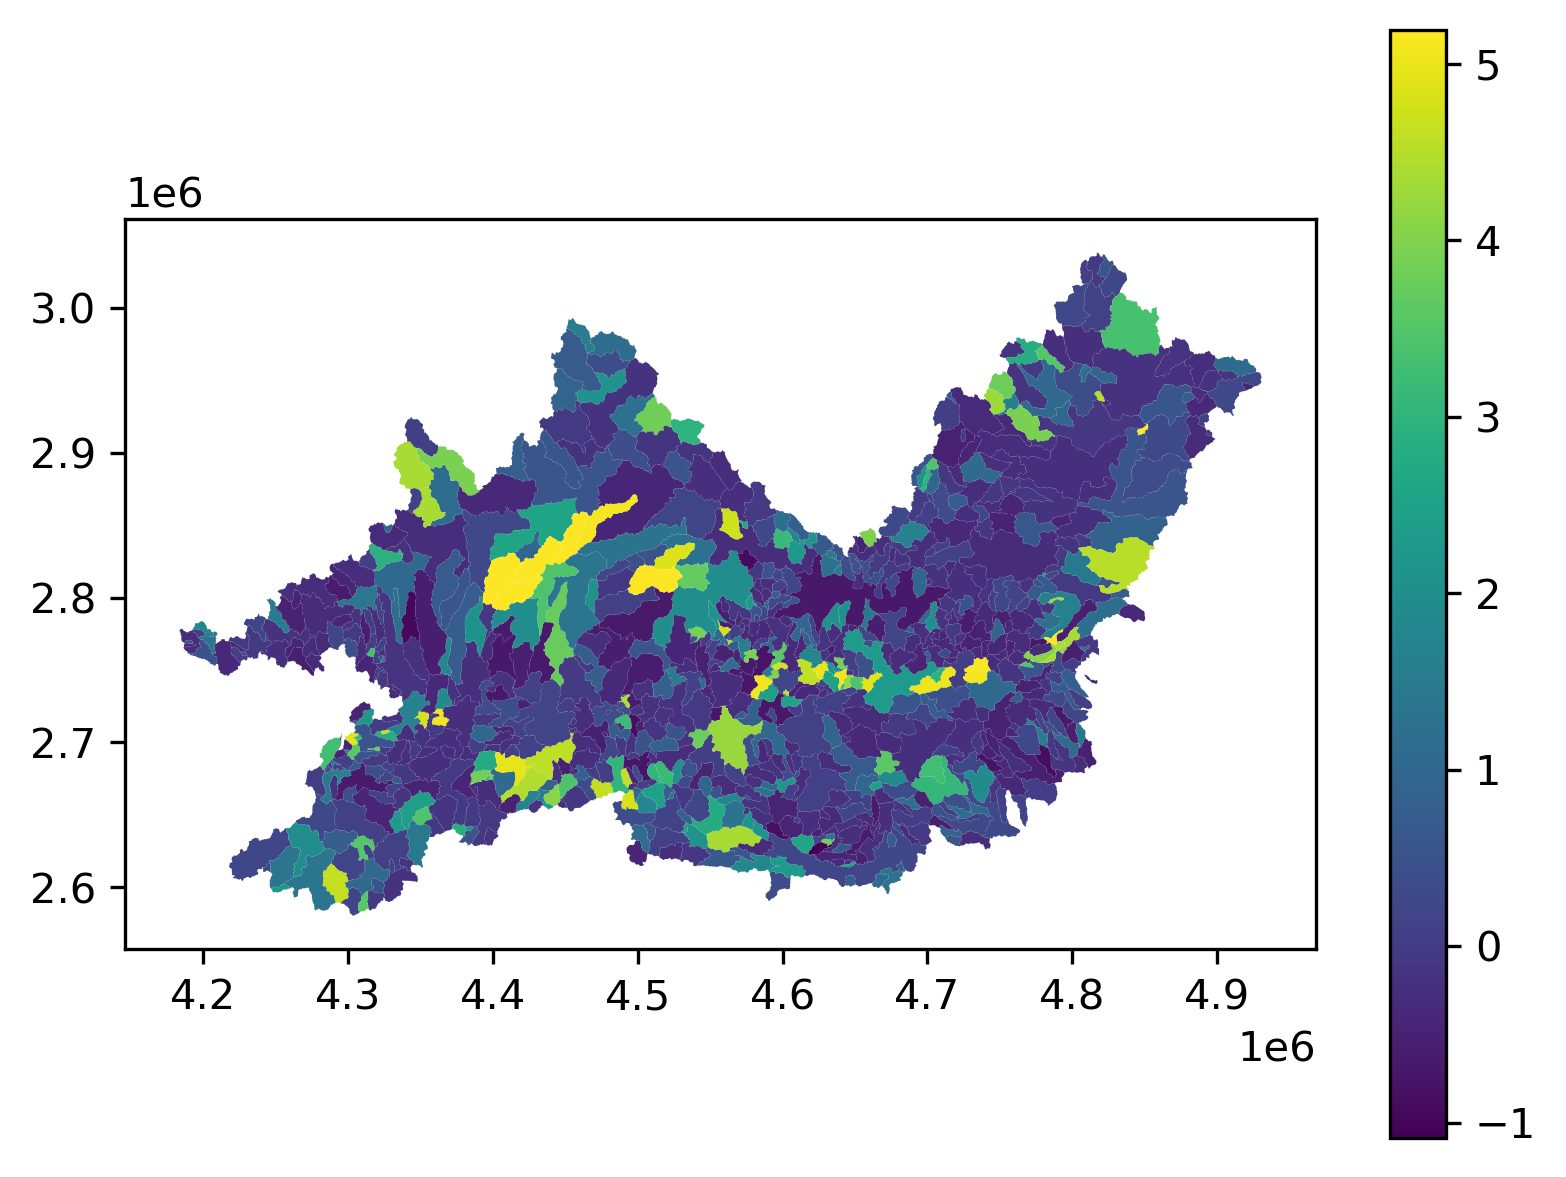

In [30]:
lamah_gdf.plot(column="urban_fra_nse_var", legend=True)

In [28]:
lamah_gdf[lamah_gdf.strata == strata_labels["plateau"]].top.value_counts()

top
arid_1        99
agr_fra       70
urban_fra     43
forest_fra    35
elev_mean     31
gvf_diff      29
bare_fra      19
frac_snow     18
hi_prec_fr    17
soil_condu    15
p_season      13
soil_poros    11
silt_fra      11
lai_max       11
sand_fra      10
p_mean         9
clay_fra       8
et0_mean       6
lo_prec_du     5
lake_fra       5
glac_fra       4
elev_ran       3
area_calc      1
hi_prec_du     1
Name: count, dtype: int64

In [ ]:
attr_categories = {
    "geomorph": ["area_calc", "slope_mean", "elev_mean", "elev_ran", "bedrk_dep"],
    "precip": ["p_mean", "p_season", "arid_1", "et0_mean", "frac_snow", "lo_prec_du", "lo_prec_fr", "hi_prec_du", "hi_prec_fr"],
    "landcover": ["urban_fra", "agr_fra", "forest_fra", "bare_fra", "lake_fra", "glac_fra"],
    "vegetation": ["gvf_max", "gvf_diff", "lai_max", "lai_diff"],
    "soil": ["clay_fra", "sand_fra", "silt_fra", "soil_condu", "soil_poros"]
}

In [ ]:
for id in lamah_gdf.index: 
	
	basin_top_attr = lamah_gdf.loc[id, "top"]

	for category, attr_list in attr_categories.items():
		if basin_top_attr in attr_list: 
			lamah_gdf.loc[id, "top_attr_category"] = category 

In [ ]:
lamah_gdf["top_attr_category"].value_counts()

top_attr_category
precip        293
landcover     265
geomorph      132
soil           95
vegetation     74
Name: count, dtype: int64

In [ ]:
lamah_gdf.iloc[:,-31:-2].columns

Index(['3rd', 'area_calc_nse_var', 'elev_mean_nse_var', 'elev_ran_nse_var',
       'slope_mean_nse_var', 'p_mean_nse_var', 'et0_mean_nse_var',
       'arid_1_nse_var', 'p_season_nse_var', 'hi_prec_fr_nse_var',
       'hi_prec_du_nse_var', 'lo_prec_fr_nse_var', 'lo_prec_du_nse_var',
       'frac_snow_nse_var', 'agr_fra_nse_var', 'bare_fra_nse_var',
       'forest_fra_nse_var', 'glac_fra_nse_var', 'lake_fra_nse_var',
       'urban_fra_nse_var', 'lai_max_nse_var', 'lai_diff_nse_var',
       'gvf_max_nse_var', 'gvf_diff_nse_var', 'bedrk_dep_nse_var',
       'soil_poros_nse_var', 'soil_condu_nse_var', 'sand_fra_nse_var',
       'silt_fra_nse_var'],
      dtype='object')

In [15]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS


kmeans = KMeans(3, random_state=1277)

cluster_labels = kmeans.fit_predict(lamah_gdf.iloc[:,-31:-2])

lamah_gdf["labels"] = cluster_labels

fig, ax = plt.subplots(3,1, figsize=(10,10))

lamah_gdf.plot(column="labels", ax=ax[0])
lamah_gdf.plot(column="top_attr_category", ax=ax[1], legend=True)
lamah_gdf.plot(column="3rd", ax=ax[2])

plt.tight_layout()

ValueError: could not convert string to float: 'gvf_diff'